# Continuous Variable Quantum Teleportation

This project explores continuous-variable (CV) quantum teleportation using multiple complementary approaches:

- Gaussian phase-space formalism (covariance matrices)
- Fock-space simulation (QuTiP)
- Wigner function visualization
- Noise and loss modeling
- Parameter sweeps and interactive tools
- Cluster-state perspective

The goal is to understand both the physics and implementation of CV teleportation.

In [ ]:
!pip install qutip thewalrus ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from thewalrus.symplectic import two_mode_squeezing, beam_splitter
from qutip import *
from ipywidgets import interact

## Gaussian Formalism

Continuous-variable quantum states can be described using:

- Mean vector (first moments)
- Covariance matrix (second moments)

Gaussian states are fully characterized by these quantities, making them efficient to simulate.

# SECTION A: GAUSSIAN STATES

In [ ]:
def vacuum_cov(n):
    return np.eye(2*n)

def coherent_mean(alpha):
    return np.array([np.sqrt(2)*np.real(alpha), np.sqrt(2)*np.imag(alpha)])

The vacuum state has identity covariance.

A coherent state is a displaced vacuum state, where the displacement encodes information.

In [ ]:
def epr_state(r):
    S = two_mode_squeezing(r)
    sigma = S @ vacuum_cov(2) @ S.T
    d = np.zeros(4)
    return d, sigma

The two-mode squeezed (EPR) state provides entanglement between Alice and Bob.

Increasing squeezing strengthens correlations and improves teleportation fidelity.

# SEC B: SQEEZING PARAMETER & TELEPORTATION FIDELITY

In [ ]:
def teleportation_fidelity(r):
    return 1 / (1 + np.exp(-2*r))

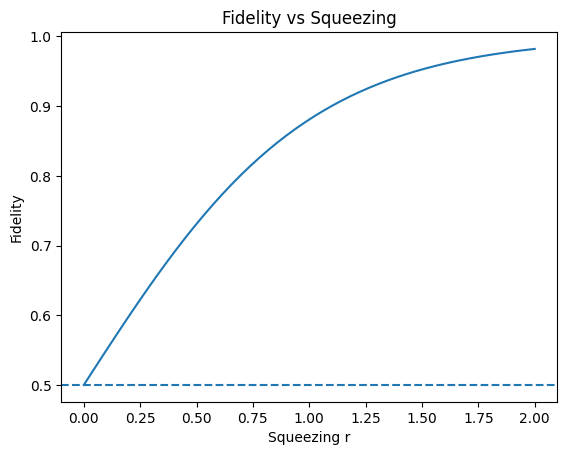

In [ ]:
r_vals = np.linspace(0,2,50)
F_vals = [teleportation_fidelity(r) for r in r_vals]

plt.plot(r_vals, F_vals)
plt.axhline(0.5, linestyle='--')
plt.xlabel("Squeezing r")
plt.ylabel("Fidelity")
plt.title("Fidelity vs Squeezing")
plt.show()

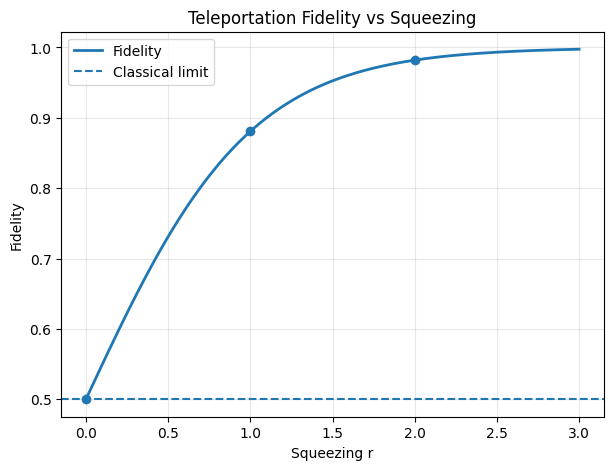

In [ ]:
r_vals = np.linspace(0, 3, 300)  # more points + extended range
F_vals = [teleportation_fidelity(r) for r in r_vals]

plt.figure(figsize=(7,5))

plt.plot(r_vals, F_vals, label="Fidelity", linewidth=2)

# Classical limit
plt.axhline(0.5, linestyle='--', label='Classical limit')

# Add markers at key points
plt.scatter([0, 1, 2],
            [teleportation_fidelity(0), teleportation_fidelity(1), teleportation_fidelity(2)],
            zorder=3)

plt.xlabel("Squeezing r")
plt.ylabel("Fidelity")
plt.title("Teleportation Fidelity vs Squeezing")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

Fidelity increases with squeezing.

- Classical limit: 0.5  
- Quantum teleportation: F > 0.5  

Perfect teleportation requires infinite squeezing.

# SECTION C: NOISE & LOSS

In [ ]:
def teleportation_with_loss(r, eta):
    F_ideal = 1 / (1 + np.exp(-2*r))
    return eta * F_ideal

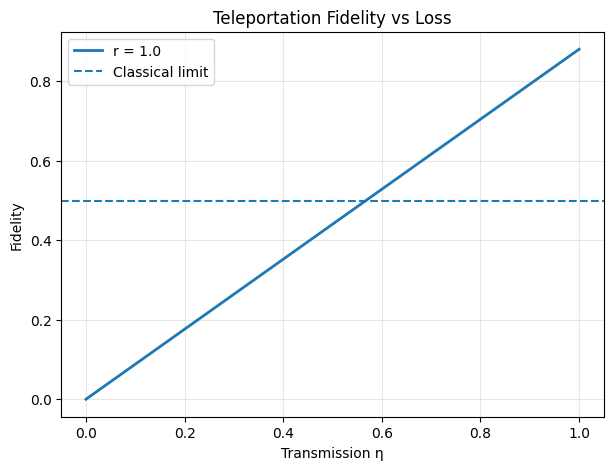

In [ ]:
eta_vals = np.linspace(0, 1, 200)
r = 1.0  # fixed squeezing

F_loss = [teleportation_with_loss(r, eta) for eta in eta_vals]

plt.figure(figsize=(7,5))

plt.plot(eta_vals, F_loss, linewidth=2, label=f"r = {r}")

# Classical limit
plt.axhline(0.5, linestyle='--', label='Classical limit')

plt.xlabel("Transmission η")
plt.ylabel("Fidelity")
plt.title("Teleportation Fidelity vs Loss")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

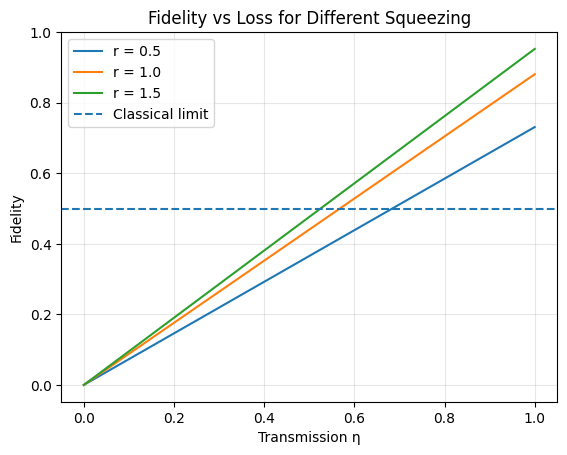

In [ ]:
for r in [0.5, 1.0, 1.5]:
    F_loss = [teleportation_with_loss(r, eta) for eta in eta_vals]
    plt.plot(eta_vals, F_loss, label=f"r = {r}")

plt.axhline(0.5, linestyle='--', label='Classical limit')
plt.xlabel("Transmission η")
plt.ylabel("Fidelity")
plt.title("Fidelity vs Loss for Different Squeezing")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Loss reduces teleportation fidelity by introducing noise and attenuating the signal.

Even with strong squeezing, high loss can destroy quantum advantage.

TELEPORTATION WITH PHYSICAL LOSS

In [ ]:
def teleportation_with_physical_loss(r, eta, alpha=1.0, g=1.0):
    d_in = coherent_mean(alpha)

    # Noise from finite squeezing
    noise_std = np.exp(-r)

    # Alice measurement (same as before)
    m_x = d_in[0] + np.random.normal(0, noise_std)
    m_p = d_in[1] + np.random.normal(0, noise_std)

    measurement = np.array([m_x, m_p])

    # Bob reconstructs
    d_recon = g * measurement

    # 🔥 Apply physical loss (beam splitter model)
    vacuum_noise = np.random.normal(0, 1, size=2)

    d_out = np.sqrt(eta) * d_recon + np.sqrt(1 - eta) * vacuum_noise

    return d_in, d_out

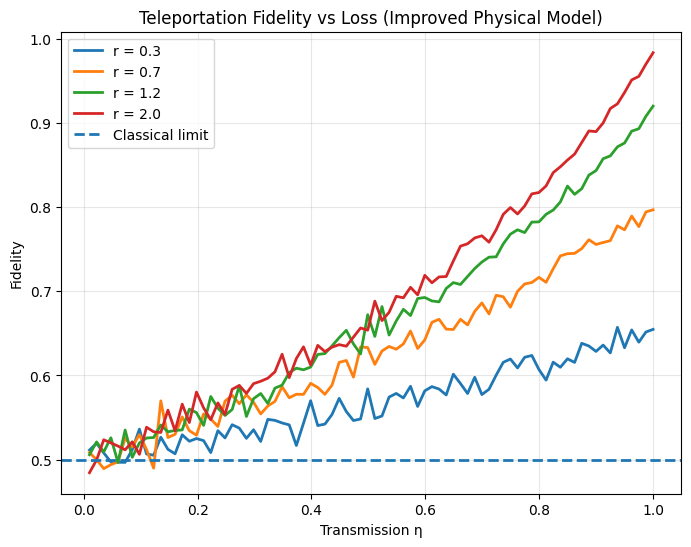

In [ ]:
# ---- PARAMETERS ----
eta_vals = np.linspace(0.01, 1, 80)  # avoid eta=0 edge
r_list = [0.3, 0.7, 1.2, 2.0]

plt.figure(figsize=(8,6))

for r in r_list:
    fidelities = []

    for eta in eta_vals:
        outputs = []

        # collect samples
        for _ in range(400):
            d_in, d_out = teleportation_with_physical_loss(r, eta)
            outputs.append(d_out)

        outputs = np.array(outputs)

        # compute variance (noise strength)
        var_x = np.var(outputs[:,0])
        var_p = np.var(outputs[:,1])
        noise = (var_x + var_p) / 2

        # Gaussian fidelity approximation
        F = 1 / (1 + noise)
        fidelities.append(F)

    plt.plot(eta_vals, fidelities, linewidth=2, label=f"r = {r}")

# Classical limit
plt.axhline(0.5, linestyle='--', linewidth=2, label="Classical limit")

plt.xlabel("Transmission η")
plt.ylabel("Fidelity")
plt.title("Teleportation Fidelity vs Loss (Improved Physical Model)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
def teleportation_with_physical_loss2(r, eta, alpha=1.0, g=1.0):
    d_in = coherent_mean(alpha)

    # Noise from finite squeezing
    noise_std = np.exp(-r)

    # Alice measurement (same as before)
    m_x = d_in[0] + np.random.normal(0, noise_std)
    m_p = d_in[1] + np.random.normal(0, noise_std)

    measurement = np.array([m_x, m_p])

    # Bob reconstructs
    g = 1 / np.sqrt(eta) if eta > 0 else 0
    d_recon = g * measurement

    # Apply physical loss (beam splitter model)
    vacuum_noise = np.random.normal(0, 1, size=2)

    d_out = np.sqrt(eta) * d_recon + np.sqrt(1 - eta) * vacuum_noise

    return d_in, d_out

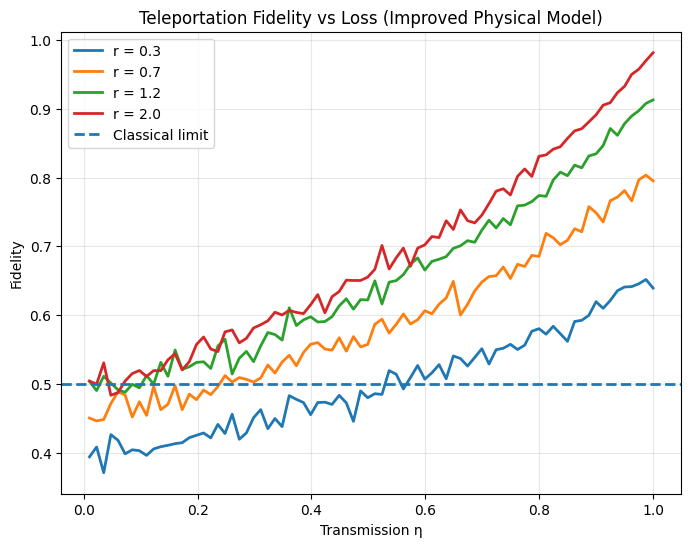

In [ ]:
# ---- PARAMETERS ----
eta_vals = np.linspace(0.01, 1, 80)  # avoid eta=0 edge
r_list = [0.3, 0.7, 1.2, 2.0]

plt.figure(figsize=(8,6))

for r in r_list:
    fidelities = []

    for eta in eta_vals:
        outputs = []

        # collect samples
        for _ in range(400):
            d_in, d_out = teleportation_with_physical_loss2(r, eta)
            outputs.append(d_out)

        outputs = np.array(outputs)

        # compute variance (noise strength)
        var_x = np.var(outputs[:,0])
        var_p = np.var(outputs[:,1])
        # total squared error (includes both spread + bias naturally)
        total_error = np.mean(np.sum((outputs - d_in)**2, axis=1))

        F = 1 / (1 + total_error/2)
        fidelities.append(F)

    plt.plot(eta_vals, fidelities, linewidth=2, label=f"r = {r}")

# Classical limit
plt.axhline(0.5, linestyle='--', linewidth=2, label="Classical limit")

plt.xlabel("Transmission η")
plt.ylabel("Fidelity")
plt.title("Teleportation Fidelity vs Loss (Improved Physical Model)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

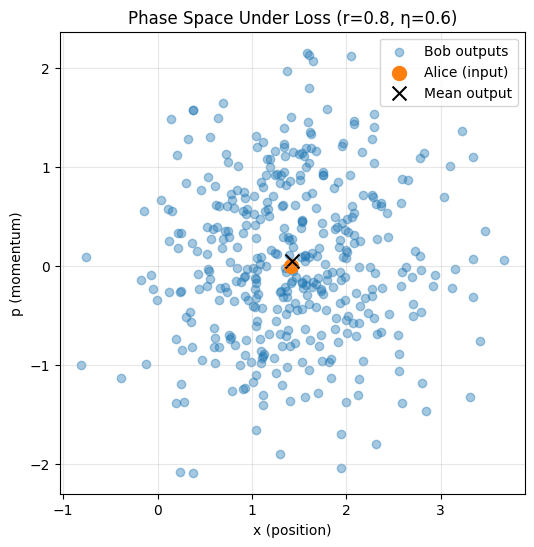

In [ ]:
# ---- PHASE SPACE CLOUD UNDER LOSS ----
r = 0.8
eta = 0.6

outputs = []
d_in = coherent_mean(1.0)

for _ in range(400):
    _, d_out = teleportation_with_physical_loss2(r, eta)
    outputs.append(d_out)

outputs = np.array(outputs)

plt.figure(figsize=(6,6))

plt.scatter(outputs[:,0], outputs[:,1], alpha=0.4, label="Bob outputs")
plt.scatter(d_in[0], d_in[1], s=100, label="Alice (input)")

mean_out = np.mean(outputs, axis=0)
plt.scatter(mean_out[0], mean_out[1], marker='x', s=100, label="Mean output", color='black')

# Labels

plt.xlabel("x (position)")
plt.ylabel("p (momentum)")
plt.title(f"Phase Space Under Loss (r={r}, η={eta})")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# SECTION D: PARAMETER SWEEP

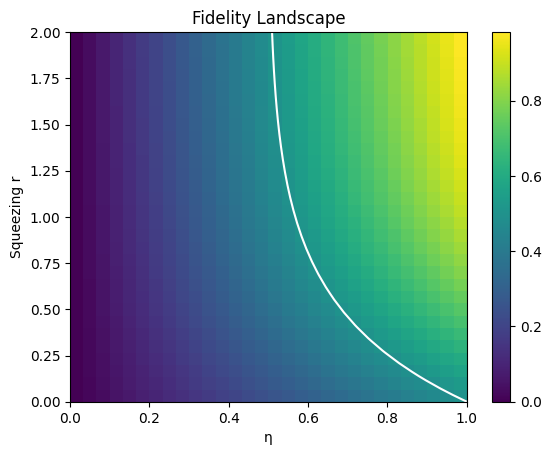

In [ ]:
r_vals = np.linspace(0,2,30)
eta_vals = np.linspace(0,1,30)

Z = np.zeros((len(r_vals), len(eta_vals)))

for i,r in enumerate(r_vals):
    for j,eta in enumerate(eta_vals):
        Z[i,j] = teleportation_with_loss(r, eta)

plt.imshow(Z, extent=[0,1,0,2], aspect='auto', origin='lower')
plt.xlabel("η")
plt.ylabel("Squeezing r")
plt.title("Fidelity Landscape")
plt.colorbar()
plt.contour(eta_vals, r_vals, Z, levels=[0.5], colors='white')
plt.show()

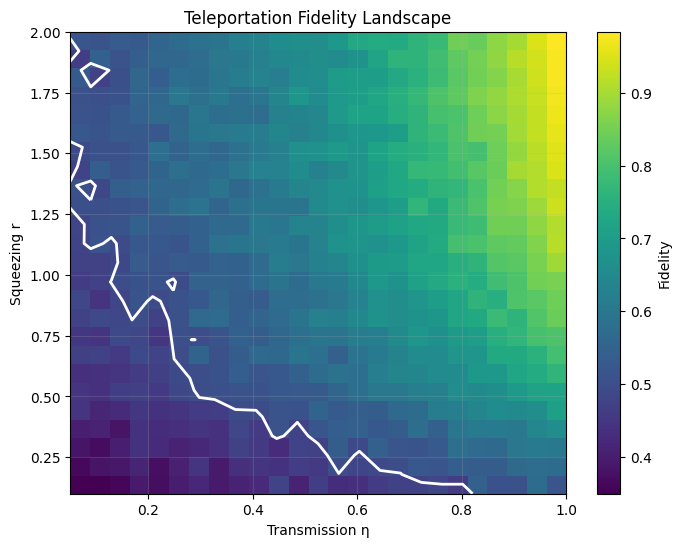

In [ ]:
# ---- PARAMETERS ----
r_vals = np.linspace(0.1, 2.0, 25)
eta_vals = np.linspace(0.05, 1.0, 25)

Z = np.zeros((len(r_vals), len(eta_vals)))

# ---- SWEEP ----
for i, r in enumerate(r_vals):
    for j, eta in enumerate(eta_vals):
        outputs = []

        for _ in range(200):
            d_in, d_out = teleportation_with_physical_loss2(r, eta)
            outputs.append(d_out)

        outputs = np.array(outputs)

        # total squared error (correct metric)
        total_error = np.mean(np.sum((outputs - d_in)**2, axis=1))

        # normalized fidelity
        F = 1 / (1 + total_error / 2)

        Z[i, j] = F

# ---- PLOT ----
plt.figure(figsize=(8,6))

im = plt.imshow(
    Z,
    extent=[eta_vals.min(), eta_vals.max(), r_vals.min(), r_vals.max()],
    origin='lower',
    aspect='auto'
)

plt.colorbar(im, label="Fidelity")

plt.xlabel("Transmission η")
plt.ylabel("Squeezing r")
plt.title("Teleportation Fidelity Landscape")

# Quantum-classical boundary
plt.contour(
    eta_vals,
    r_vals,
    Z,
    levels=[0.5],
    colors='white',
    linewidths=2
)

plt.grid(alpha=0.2)

plt.show()

This 2D plot shows how teleportation depends on both squeezing and loss.

Optimal performance requires:
- High squeezing
- Low loss

# SECTION E: FOCK SPACE

In [ ]:
N = 20
psi = coherent(N, 1.0)

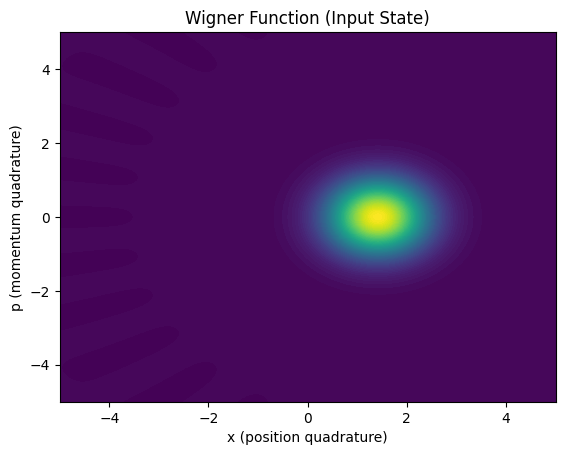

In [ ]:
x = np.linspace(-5,5,200)
W = wigner(psi, x, x)

plt.contourf(x, x, W, 100)
plt.xlabel("x (position quadrature)")
plt.ylabel("p (momentum quadrature)")
plt.title("Wigner Function (Input State)")
plt.show()

The Wigner function provides a phase-space representation of quantum states.

For coherent states, it is Gaussian and centered at the displacement.

# SECTION F:  NOISY OUTPUT VISUALISATION

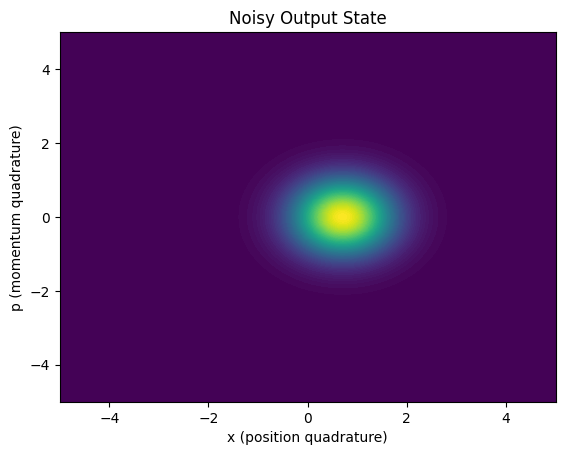

In [ ]:
psi2 = coherent(N, 0.5)
W2 = wigner(psi2, x, x)

plt.contourf(x, x, W2, 100)
plt.xlabel("x (position quadrature)")
plt.ylabel("p (momentum quadrature)")
plt.title("Noisy Output State")
plt.show()

Noise broadens and shifts the Wigner distribution, reflecting degradation during teleportation.

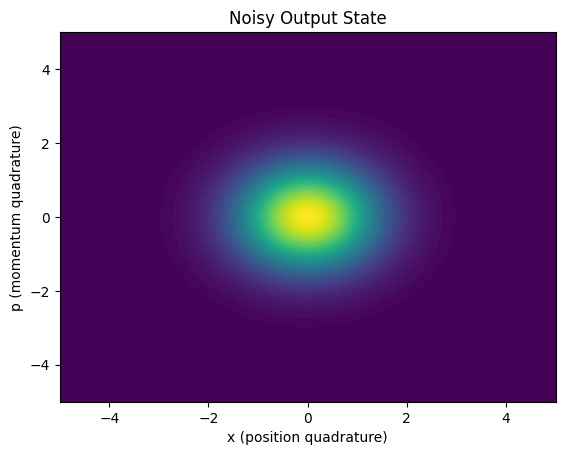

In [ ]:
psi2 = thermal_dm(N, 0.5)  # thermal state (noisy)

W2 = wigner(psi2, x, x)

plt.contourf(x, x, W2, 100)
plt.xlabel("x (position quadrature)")
plt.ylabel("p (momentum quadrature)")
plt.title("Noisy Output State")
plt.show()

# SECTION G: CLUSTER STATES

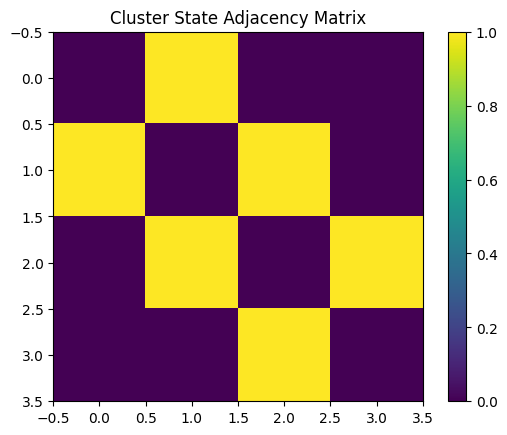

In [ ]:
def cluster_adjacency(n):
    A = np.zeros((n,n))
    for i in range(n-1):
        A[i,i+1] = 1
        A[i+1,i] = 1
    return A

A = cluster_adjacency(4)

plt.imshow(A)
plt.title("Cluster State Adjacency Matrix")
plt.colorbar()
plt.show()

Cluster states are multi-mode entangled states used in measurement-based quantum computing.

Teleportation can be viewed as a primitive operation within this framework.

Prepare a chain of entangled modes, then measure intermediate nodes; the input state “hops” along the chain to the last node, picking up noise at each step.

In [ ]:
def teleport_through_cluster(L, r, eta=1.0, alpha=1.0):
    """
    L = number of nodes in chain
    r = squeezing
    eta = transmission (per hop)
    alpha = input coherent amplitude
    """
    d = coherent_mean(alpha)  # start at node 1

    for step in range(L - 1):
        # measurement noise (finite squeezing)
        noise_std = np.exp(-r)
        m_x = d[0] + np.random.normal(0, noise_std)
        m_p = d[1] + np.random.normal(0, noise_std)
        measurement = np.array([m_x, m_p])

        # gain (compensate loss)
        g = 1 / np.sqrt(eta) if eta > 0 else 0
        d_recon = g * measurement

        # loss (beam splitter with vacuum)
        vacuum = np.random.normal(0, 1, size=2)
        d = np.sqrt(eta) * d_recon + np.sqrt(1 - eta) * vacuum

    return coherent_mean(alpha), d

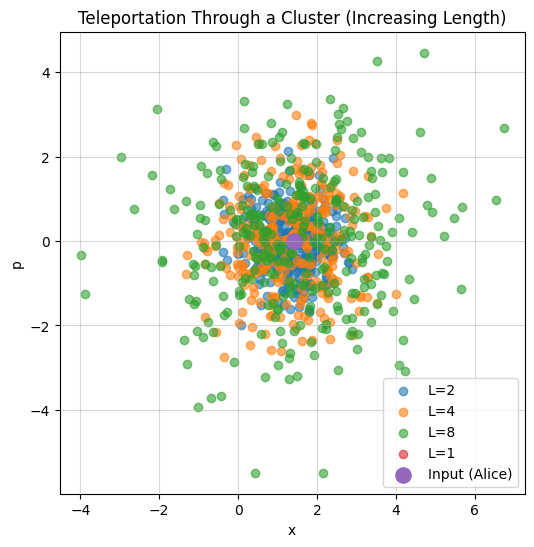

In [ ]:
L_list = [2, 4, 8, 1]
r = 0.8
eta = 0.8
samples = 300

d_in = coherent_mean(1.0)

plt.figure(figsize=(6,6))

for L in L_list:
    outputs = []
    for _ in range(samples):
        _, d_out = teleport_through_cluster(L, r, eta)
        outputs.append(d_out)
    outputs = np.array(outputs)

    plt.scatter(outputs[:,0], outputs[:,1], alpha=0.6, label=f"L={L}")

plt.scatter(d_in[0], d_in[1], s=120, label="Input (Alice)")
plt.xlabel("x")
plt.ylabel("p")
plt.title("Teleportation Through a Cluster (Increasing Length)")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

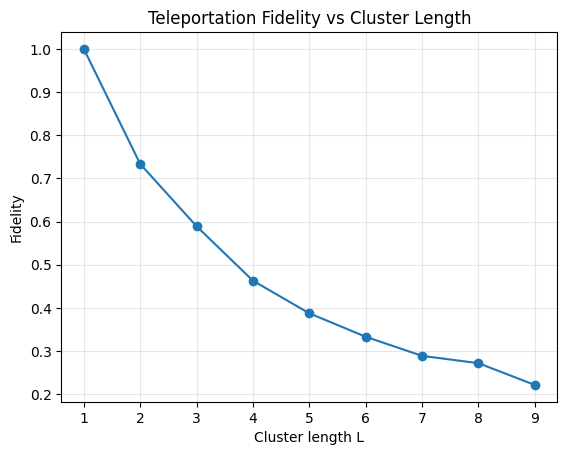

In [ ]:
L_vals = range(1, 10)
fidelities = []

for L in L_vals:
    errors = []
    for _ in range(300):
        d_in, d_out = teleport_through_cluster(L, r=0.8, eta=0.8)
        errors.append(np.sum((d_out - d_in)**2))

    total_error = np.mean(errors)
    F = 1 / (1 + total_error / 2)
    fidelities.append(F)

plt.plot(L_vals, fidelities, marker='o')
plt.xlabel("Cluster length L")
plt.ylabel("Fidelity")
plt.title("Teleportation Fidelity vs Cluster Length")
plt.grid(alpha=0.3)
plt.show()

A cluster state acts like a noisy communication channel with length-dependent degradation

# SECTION H

In [ ]:
def interactive_plot(r=0.5, eta=0.8):
    F = teleportation_with_loss(r, eta)
    print(f"Fidelity = {F:.4f}")

interact(interactive_plot, r=(0,2,0.05), eta=(0,1,0.05))

interactive(children=(FloatSlider(value=0.5, description='r', max=2.0, step=0.05), FloatSlider(value=0.8, desc…

<function __main__.interactive_plot(r=0.5, eta=0.8)>

This interactive tool allows real-time exploration of teleportation performance.

We can vary squeezing and loss to understand their combined effects.

# Conclusion

We studied continuous-variable quantum teleportation through:

- Gaussian covariance matrix methods
- Fock-space simulations
- Wigner function visualization
- Noise and loss modeling
- Parameter sweeps and interactive tools

This multi-perspective approach provides both physical intuition and computational insight into quantum teleportation.

# Explicit Teleportation Protocol (Alice → Bob)

We now simulate the teleportation protocol step-by-step:

1. Alice holds:
   - The unknown input state
   - One mode of the EPR pair

2. She performs a joint (Bell-like) measurement.

3. She sends the measurement results (classical numbers) to Bob.

4. Bob applies a displacement operation using this information.

This explicitly demonstrates how the quantum state is transferred.

The effect of finite EPR squeezing is replaced by Gaussian noise with variance.
So instead of building EPR and evolving full quantum state

We directly model:
“What does EPR do to the teleportation?”

In [ ]:
def teleportation_protocol(r, alpha=1.0, g=1.0):
    d_in = coherent_mean(alpha)

    noise_std = np.exp(-r)

    # Alice measurement
    m_x = d_in[0] + np.random.normal(0, noise_std)
    m_p = d_in[1] + np.random.normal(0, noise_std)

    measurement = np.array([m_x, m_p])

    # Bob applies gain
    d_out = g * measurement

    return d_in, d_out

In [ ]:
d_in, d_out = teleportation_protocol(r=0.8, alpha=1.0)

print("Input state (Alice):", d_in)
print("Output state (Bob):", d_out)

Input state (Alice): [1.41421356 0.        ]
Output state (Bob): [1.46805997 0.16989032]


Alice performs a measurement and sends two classical numbers to Bob.

Bob uses this information to reconstruct the state via displacement.

Due to finite squeezing, noise is introduced, so the output is not identical to the input.

In [ ]:
d_in, d_out = teleportation_protocol(r=0.2, alpha=1.0)

print("Input state (Alice):", d_in)
print("Output state (Bob):", d_out)

Input state (Alice): [1.41421356 0.        ]
Output state (Bob): [1.90528817 0.83384896]


In [ ]:
d_in, d_out = teleportation_protocol(r=2.0, alpha=1.0)

print("Input state (Alice):", d_in)
print("Output state (Bob):", d_out)

Input state (Alice): [1.41421356 0.        ]
Output state (Bob): [ 1.38007099 -0.13875768]


In [ ]:
def plot_teleportation_phase_space(d_in, d_out):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,6))

    # Plot points
    plt.scatter(d_in[0], d_in[1], label="Input (Alice)", s=80)
    plt.scatter(d_out[0], d_out[1], label="Output (Bob)", s=80)

    # Arrow from input to output
    plt.arrow(d_in[0], d_in[1],
              d_out[0] - d_in[0],
              d_out[1] - d_in[1],
              head_width=0.03,
              length_includes_head=True)

    # Labels near points
    # Alice label
    plt.text(d_in[0] + 0.05, d_in[1] + 0.05, f"Alice\n({d_in[0]:.2f}, {d_in[1]:.2f})",fontsize=10, ha='left')

    # Bob label
    plt.text(d_out[0] + 0.05, d_out[1] - 0.08,f"Bob\n({d_out[0]:.2f}, {d_out[1]:.2f})",fontsize=10, ha='left')

    # Axis labels
    plt.xlabel("x (position quadrature)")
    plt.ylabel("p (momentum quadrature)")

    plt.title("Quantum Teleportation in Phase Space")

    # Centered axes for better visualization
    plt.xlim(min(d_in[0], d_out[0]) - 0.5, max(d_in[0], d_out[0]) + 0.5)
    plt.ylim(min(d_in[1], d_out[1]) - 0.5, max(d_in[1], d_out[1]) + 0.5)

    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

In [ ]:
d_in, d_out = teleportation_protocol(r=0.8, alpha=1.0)

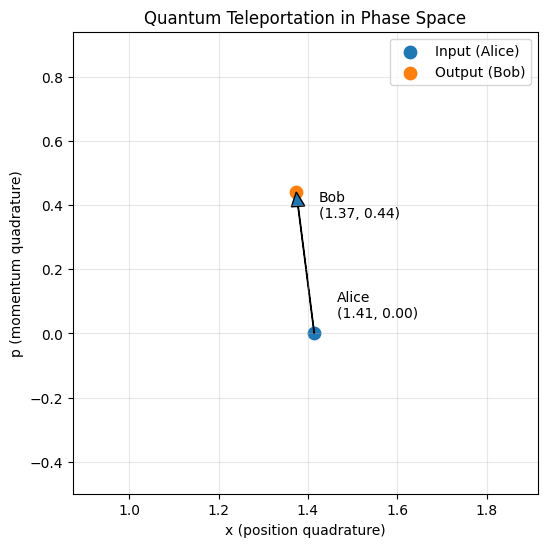

In [ ]:
plot_teleportation_phase_space(d_in, d_out)

This phase-space plot shows:

- The original state (Alice)
- The reconstructed state (Bob)

As squeezing increases, the two points converge.

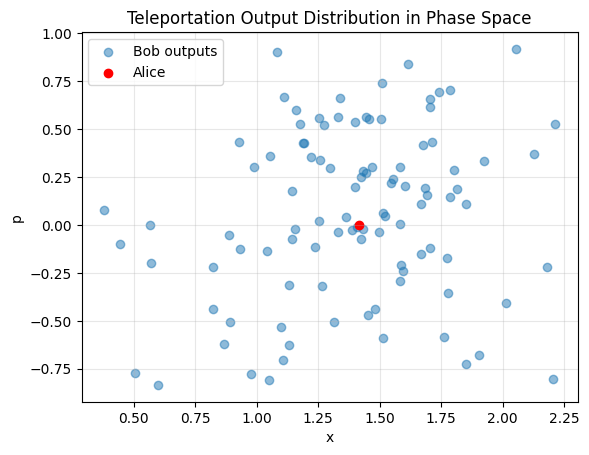

In [ ]:
d_in = coherent_mean(1.0)

outputs = []
for _ in range(100):
    _, d_out = teleportation_protocol(r=0.8)
    outputs.append(d_out)

outputs = np.array(outputs)

plt.scatter(outputs[:,0], outputs[:,1], alpha=0.5, label="Bob outputs")
plt.scatter(d_in[0], d_in[1], color='red', label="Alice")

plt.xlabel("x")
plt.ylabel("p")
plt.title("Teleportation Output Distribution in Phase Space")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

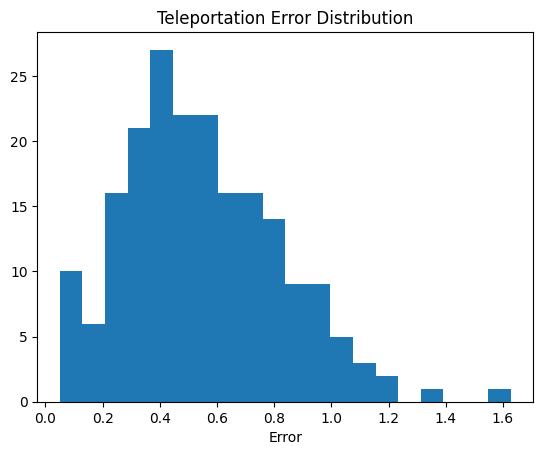

In [ ]:
errors = []

for _ in range(200):
    d_in, d_out = teleportation_protocol(r=0.8)
    errors.append(np.linalg.norm(d_in - d_out))

plt.hist(errors, bins=20)
plt.title("Teleportation Error Distribution")
plt.xlabel("Error")
plt.show()

This histogram shows the distribution of teleportation errors.

Higher squeezing reduces the spread, improving teleportation accuracy.

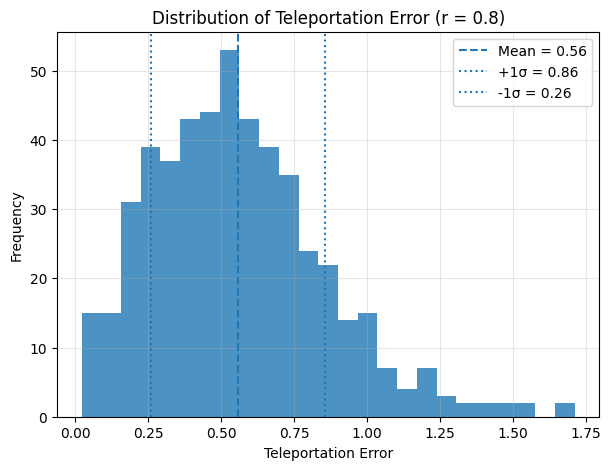

In [ ]:
errors = []

# Collect many samples (important for smooth histogram)
for _ in range(500):
    d_in, d_out = teleportation_protocol(r=0.8)
    errors.append(np.linalg.norm(d_in - d_out))

# Convert to numpy array (optional but useful)
errors = np.array(errors)

# Compute statistics
mean = np.mean(errors)
std = np.std(errors)

# Plot
plt.figure(figsize=(7,5))

plt.hist(errors, bins=25, alpha=0.8)

# Mean and standard deviation lines
plt.axvline(mean, linestyle='--', label=f"Mean = {mean:.2f}")
plt.axvline(mean + std, linestyle=':', label=f"+1σ = {mean+std:.2f}")
plt.axvline(mean - std, linestyle=':', label=f"-1σ = {mean-std:.2f}")

plt.xlabel("Teleportation Error")
plt.ylabel("Frequency")
plt.title("Distribution of Teleportation Error (r = 0.8)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

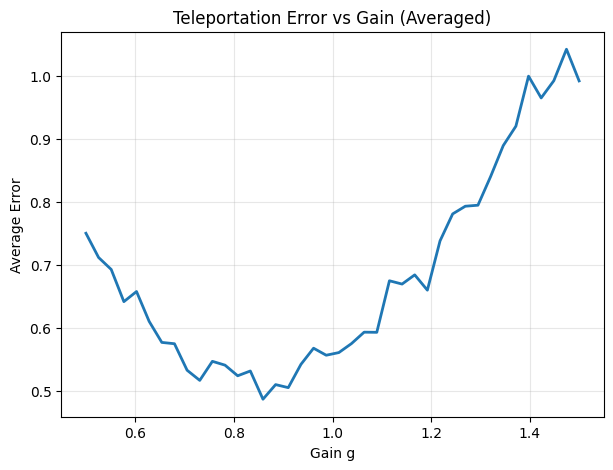

In [ ]:
g_vals = np.linspace(0.5, 1.5, 40)
avg_errors = []

for g in g_vals:
    errors = []

    # average over many runs
    for _ in range(300):
        d_in, d_out = teleportation_protocol(r=0.8, g=g)
        errors.append(np.linalg.norm(d_in - d_out))

    avg_errors.append(np.mean(errors))

# Plot
plt.figure(figsize=(7,5))

plt.plot(g_vals, avg_errors, linewidth=2)

plt.xlabel("Gain g")
plt.ylabel("Average Error")
plt.title("Teleportation Error vs Gain (Averaged)")

plt.grid(alpha=0.3)

plt.show()

The gain parameter controls how Bob reconstructs the state.

- Optimal gain (g ≈ 1) minimizes teleportation error
- Incorrect gain leads to systematic distortion

This reflects the importance of calibration in experimental implementations.

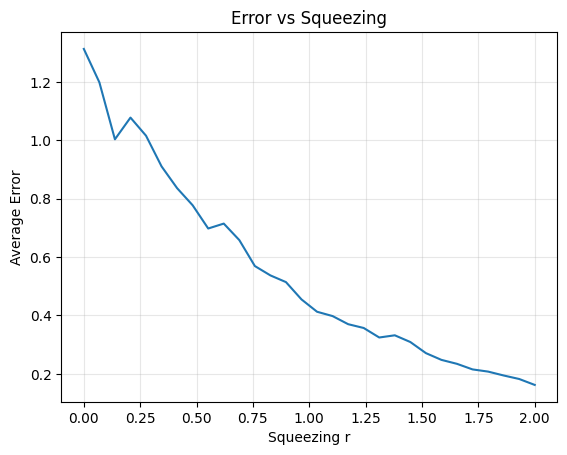

In [ ]:
r_vals = np.linspace(0,2,30)
avg_errors = []

for r in r_vals:
    errs = []
    for _ in range(200):
        d_in, d_out = teleportation_protocol(r=r)
        errs.append(np.linalg.norm(d_in - d_out))
    avg_errors.append(np.mean(errs))

plt.plot(r_vals, avg_errors)
plt.xlabel("Squeezing r")
plt.ylabel("Average Error")
plt.title("Error vs Squeezing")
plt.grid(alpha=0.3)
plt.show()

#CLASSICAL PROTOCOL COMPARISON

In [ ]:
def classical_protocol(alpha=1.0):
    d_in = coherent_mean(alpha)
    noise = np.random.normal(0, 1, size=2)
    return d_in, noise  # random guess

# Compare errors

In [ ]:
quantum_errors = []
classical_errors = []

for _ in range(500):
    # Quantum teleportation
    d_in, d_out = teleportation_protocol(r=0.8)
    quantum_errors.append(np.linalg.norm(d_in - d_out))

    # Classical attempt
    d_in, d_out_classical = classical_protocol()
    classical_errors.append(np.linalg.norm(d_in - d_out_classical))

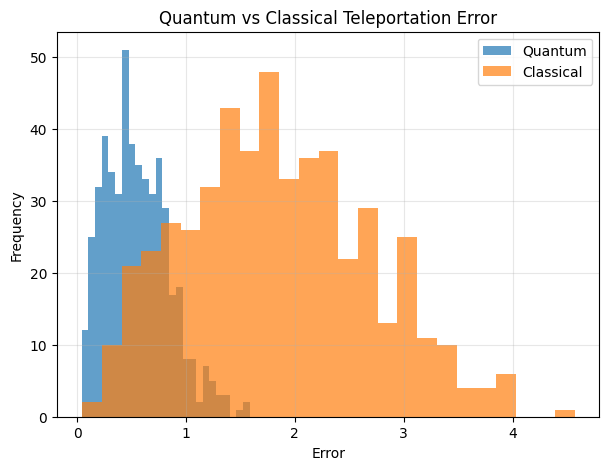

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(quantum_errors, bins=25, alpha=0.7, label="Quantum")
plt.hist(classical_errors, bins=25, alpha=0.7, label="Classical")

plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Quantum vs Classical Teleportation Error")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

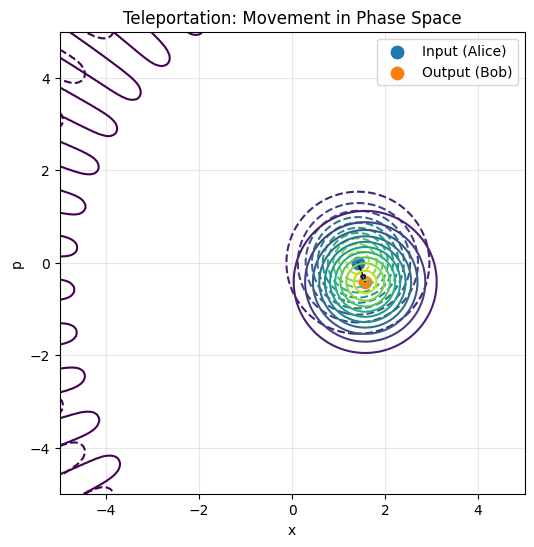

In [ ]:
from qutip import coherent, wigner
import numpy as np
import matplotlib.pyplot as plt

N = 30
x = np.linspace(-5,5,200)

# Run teleportation
d_in, d_out = teleportation_protocol(r=0.8, alpha=1.0)

# Convert to alpha
alpha_in = (d_in[0] + 1j*d_in[1]) / np.sqrt(2)
alpha_out = (d_out[0] + 1j*d_out[1]) / np.sqrt(2)

# States
psi_in = coherent(N, alpha_in)
psi_out = coherent(N, alpha_out)

# Wigner functions
W_in = wigner(psi_in, x, x)
W_out = wigner(psi_out, x, x)

# Plot
plt.figure(figsize=(6,6))

# Input (transparent)
plt.contour(x, x, W_in, levels=10, linestyles='dashed')

# Output (solid)
plt.contour(x, x, W_out, levels=10)

# Mark centers
plt.scatter(d_in[0], d_in[1], label="Input (Alice)", s=80)
plt.scatter(d_out[0], d_out[1], label="Output (Bob)", s=80)

# Arrow showing movement
plt.arrow(d_in[0], d_in[1],
          d_out[0] - d_in[0],
          d_out[1] - d_in[1],
          head_width=0.1,
          length_includes_head=True)

plt.xlabel("x")
plt.ylabel("p")
plt.title("Teleportation: Movement in Phase Space")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

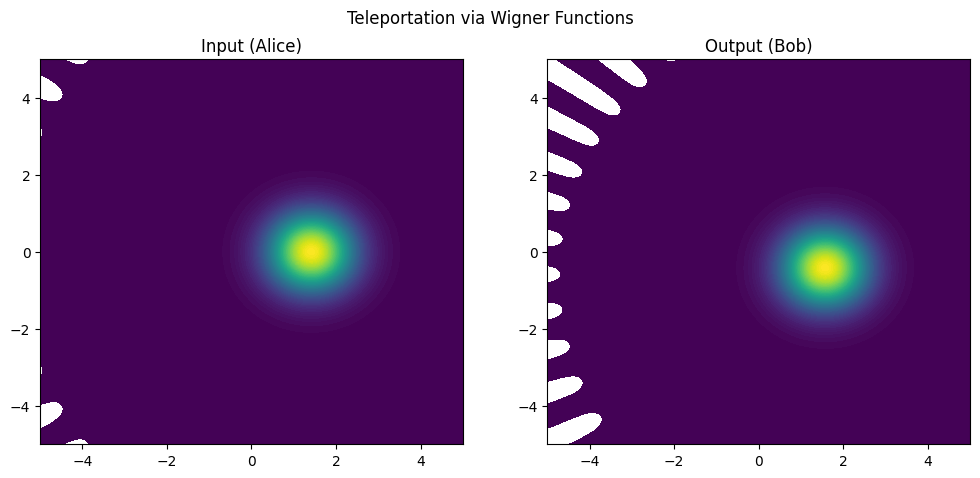

In [ ]:
# Plot
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].contourf(x, x, W_in, 100)
axes[0].set_title("Input (Alice)")

axes[1].contourf(x, x, W_out, 100)
axes[1].set_title("Output (Bob)")

plt.suptitle("Teleportation via Wigner Functions")
plt.show()

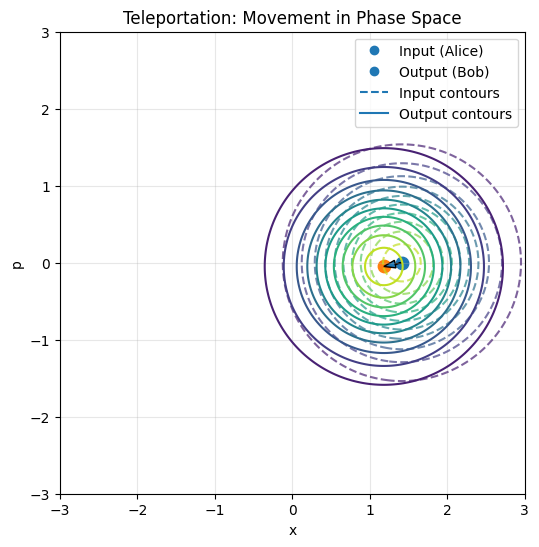

In [ ]:
from qutip import coherent, wigner
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Improved parameters (fix artifacts)
N = 40
x = np.linspace(-3, 3, 200)

# Run teleportation
d_in, d_out = teleportation_protocol(r=0.8, alpha=1.0)

# Convert to alpha
alpha_in = (d_in[0] + 1j*d_in[1]) / np.sqrt(2)
alpha_out = (d_out[0] + 1j*d_out[1]) / np.sqrt(2)

# States
psi_in = coherent(N, alpha_in)
psi_out = coherent(N, alpha_out)

# Wigner functions
W_in = wigner(psi_in, x, x)
W_out = wigner(psi_out, x, x)

# Plot
plt.figure(figsize=(6,6))

# Contours
plt.contour(x, x, W_in, levels=10, linestyles='dashed', alpha=0.7)
plt.contour(x, x, W_out, levels=10)

# Points
plt.scatter(d_in[0], d_in[1], s=80)
plt.scatter(d_out[0], d_out[1], s=80)

# Arrow (movement)
plt.arrow(d_in[0], d_in[1],
          d_out[0] - d_in[0],
          d_out[1] - d_in[1],
          head_width=0.1,
          length_includes_head=True)

# Labels
plt.xlabel("x")
plt.ylabel("p")
plt.title("Teleportation: Movement in Phase Space")

# 🔥 Clean legend
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='', label='Input (Alice)'),
    Line2D([0], [0], marker='o', linestyle='', label='Output (Bob)'),
    Line2D([0], [0], linestyle='dashed', label='Input contours'),
    Line2D([0], [0], linestyle='solid', label='Output contours')
]

plt.legend(handles=legend_elements)

plt.grid(alpha=0.3)
plt.show()

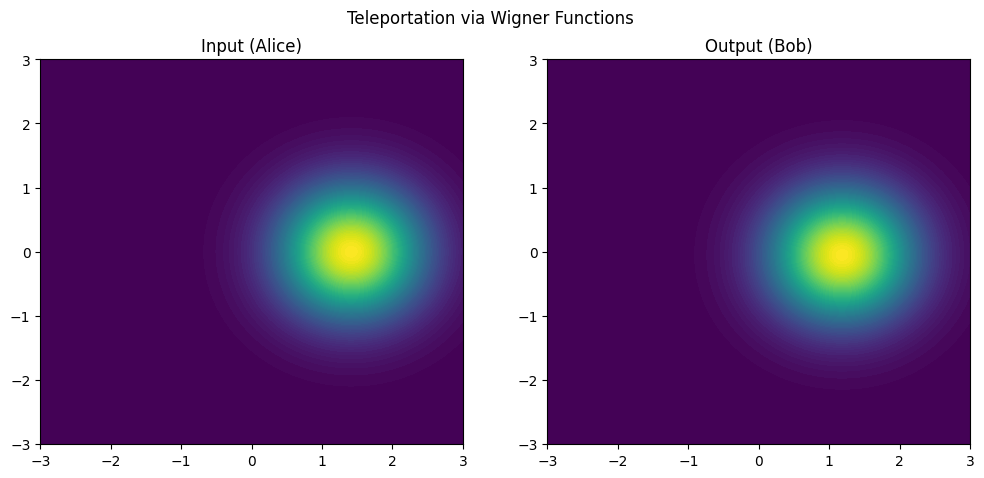

In [ ]:
# Plot
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].contourf(x, x, W_in, 100)
axes[0].set_title("Input (Alice)")

axes[1].contourf(x, x, W_out, 100)
axes[1].set_title("Output (Bob)")

plt.suptitle("Teleportation via Wigner Functions")
plt.show()